
# RQ7 Notebook — Interpretability and Operational Actionability

This notebook implements **RQ7** from the revised proposal:

> **How interpretable and operationally actionable are the predictions of these models for real-world trust-and-safety workflows?**

It is organized to go **step by step from data loading to the required RQ7 outputs**:

- **Figure RQ7-a**: global feature importance for the strongest feature-based model
- **Figure RQ7-b**: case-based explanation of operational model decisions
- **Table RQ7-a**: error analysis of selected models
- **Table RQ7-b**: operational actionability matrix

It writes all RQ7 outputs into:

- `outputs/rq7_figures/` for figures
- `outputs/rq7_tables/` for tables

All figures are saved as **PDF** files in addition to PNG.

**Patched behavior:** this notebook tries to use **XGBoost** first and automatically falls back to
**HistGradientBoostingClassifier** if XGBoost is unavailable or broken in the local environment.


In [ ]:

# Optional dependency note:
# The graph and hybrid sections require torch-geometric.
# If it is missing in your environment, install it first according to your PyTorch version:
#
# pip install torch-geometric
#
# The notebook is written so that the tabular interpretability pipeline still runs without it.


In [1]:

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import json
import time
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    matthews_corrcoef, average_precision_score, balanced_accuracy_score,
    confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier

XGB_AVAILABLE = True
try:
    from xgboost import XGBClassifier
except Exception as e:
    XGB_AVAILABLE = False
    print("XGBoost is unavailable. Falling back to HistGradientBoostingClassifier.")
    print("Import error:", e)

PYG_AVAILABLE = True
try:
    import torch
    import torch.nn.functional as F
    from torch_geometric.data import Data
    from torch_geometric.nn import SAGEConv
    from sklearn.neighbors import kneighbors_graph
except Exception as e:
    PYG_AVAILABLE = False
    print("torch-geometric is not available. Graph/hybrid sections will be skipped until installed.")
    print("Import error:", e)

PRIMARY_SEED = 42
def set_seed(seed):
    np.random.seed(seed)
    random.seed(seed)
    if PYG_AVAILABLE:
        torch.manual_seed(seed)

set_seed(PRIMARY_SEED)

DATA_PATH = Path("./Data/full_dataset.csv")
BASE_DIR = Path("")
OUT_DIR = BASE_DIR / "outputs"
RQ7_FIG_DIR = OUT_DIR / "rq7_figures"
RQ7_TABLE_DIR = OUT_DIR / "rq7_tables"
RQ7_FIG_DIR.mkdir(parents=True, exist_ok=True)
RQ7_TABLE_DIR.mkdir(parents=True, exist_ok=True)

NUMERIC_FEATURES = [
    "followers_count", "friends_count", "statuses_count",
    "favourites_count", "listed_count"
]
BINARY_FEATURES = [
    "default_profile", "default_profile_image", "geo_enabled"
]
MISSINGNESS_FEATURES = [
    "default_profile_missing", "default_profile_image_missing", "geo_enabled_missing"
]
REVISED_FEATURES = NUMERIC_FEATURES + BINARY_FEATURES + MISSINGNESS_FEATURES

print("Ready.")
print("Dataset path:", DATA_PATH)
print("Figure output dir:", RQ7_FIG_DIR)
print("Table output dir:", RQ7_TABLE_DIR)


XGBoost is unavailable. Falling back to HistGradientBoostingClassifier.
Import error: 
XGBoost Library (libxgboost.dylib) could not be loaded.
Likely causes:
  * OpenMP runtime is not installed
    - vcomp140.dll or libgomp-1.dll for Windows
    - libomp.dylib for Mac OSX
    - libgomp.so for Linux and other UNIX-like OSes
    Mac OSX users: Run `brew install libomp` to install OpenMP runtime.

  * You are running 32-bit Python on a 64-bit OS

Error message(s): ["dlopen(/Users/hashimali/.pyenv/versions/3.12.6/lib/python3.12/site-packages/xgboost/lib/libxgboost.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib\n  Referenced from: <1A0D8152-BF46-3BE0-B651-EE965C187777> /Users/hashimali/.pyenv/versions/3.12.6/lib/python3.12/site-packages/xgboost/lib/libxgboost.dylib\n  Reason: tried: '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/homebrew/opt/libomp/lib/libomp.dylib' (n

## 1. Load the dataset and create the revised 11-feature policy

In [2]:

df = pd.read_csv(DATA_PATH, low_memory=False)
required_cols = ["label"] + NUMERIC_FEATURES + BINARY_FEATURES
missing_required = [c for c in required_cols if c not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

df_work = df.copy()
for col in BINARY_FEATURES:
    df_work[f"{col}_missing"] = df_work[col].isna().astype(int)

dataset_summary = {
    "shape": list(df_work.shape),
    "label_distribution": df_work["label"].value_counts(dropna=False).to_dict(),
    "missingness": df_work[NUMERIC_FEATURES + BINARY_FEATURES].isna().mean().round(4).to_dict()
}

print("Shape:", df_work.shape)
print("Label distribution:", dataset_summary["label_distribution"])
display(pd.DataFrame([dataset_summary["missingness"]]))
display(df_work[REVISED_FEATURES + ["label"]].head())


Shape: (14368, 46)
Label distribution: {1: 10894, 0: 3474}


,followers_count,friends_count,statuses_count,favourites_count,listed_count,default_profile,default_profile_image,geo_enabled
0,0.0,0.0,0.0,0.0,0.0,0.686,0.9946,0.7611


,followers_count,friends_count,statuses_count,favourites_count,listed_count,default_profile,default_profile_image,geo_enabled,default_profile_missing,default_profile_image_missing,geo_enabled_missing,label
0,657,534,236,0,44,NaN,NaN,1.0,1,1,0,1
1,15,30,129,0,0,NaN,NaN,NaN,1,1,1,1
2,42,387,1,0,1,NaN,NaN,NaN,1,1,1,1
3,226,598,1,0,1,NaN,NaN,NaN,1,1,1,1
4,67,474,348,6,0,1.0,NaN,NaN,0,1,1,1


## 2. Define preprocessing, metrics, and helper functions

In [3]:

def compute_metrics(y_true, y_pred, y_prob=None):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro-F1": f1_score(y_true, y_pred, average="macro"),
        "Macro-Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro-Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "PR-AUC": average_precision_score(y_true, y_prob) if y_prob is not None else np.nan,
        "MCC": matthews_corrcoef(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
    }

def preprocess_split(df_in, seed=42):
    X = df_in[REVISED_FEATURES].copy()
    y = df_in["label"].astype(int).copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, stratify=y, random_state=seed
    )

    num_imputer = SimpleImputer(strategy="median")
    X_train_num = pd.DataFrame(num_imputer.fit_transform(X_train[NUMERIC_FEATURES]), columns=NUMERIC_FEATURES, index=X_train.index)
    X_test_num = pd.DataFrame(num_imputer.transform(X_test[NUMERIC_FEATURES]), columns=NUMERIC_FEATURES, index=X_test.index)

    X_train_bin = X_train[BINARY_FEATURES + MISSINGNESS_FEATURES].copy().fillna(0)
    X_test_bin = X_test[BINARY_FEATURES + MISSINGNESS_FEATURES].copy().fillna(0)

    scaler = StandardScaler()
    X_train_num_scaled = pd.DataFrame(scaler.fit_transform(X_train_num), columns=NUMERIC_FEATURES, index=X_train.index)
    X_test_num_scaled = pd.DataFrame(scaler.transform(X_test_num), columns=NUMERIC_FEATURES, index=X_test.index)

    X_train_all = pd.concat([X_train_num_scaled, X_train_bin], axis=1)[REVISED_FEATURES]
    X_test_all = pd.concat([X_test_num_scaled, X_test_bin], axis=1)[REVISED_FEATURES]

    return {
        "X_train": X_train_all,
        "X_test": X_test_all,
        "y_train": y_train,
        "y_test": y_test
    }

def get_boosting_model(seed=42):
    if XGB_AVAILABLE:
        return "XGBoost", XGBClassifier(
            n_estimators=250,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            eval_metric="logloss",
            random_state=seed
        )
    return "HistGradientBoosting", HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_depth=5,
        max_iter=250,
        random_state=seed
    )

def get_probabilities(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        raw = np.asarray(model.decision_function(X)).reshape(-1)
        return (raw - raw.min()) / (raw.max() - raw.min() + 1e-9)
    pred = model.predict(X)
    return np.asarray(pred, dtype=float)

def feature_importance_df(model, feature_names):
    if hasattr(model, "feature_importances_"):
        vals = np.asarray(model.feature_importances_, dtype=float)
    else:
        # fallback for non-tree model
        vals = np.repeat(1.0 / len(feature_names), len(feature_names))
    out = pd.DataFrame({"Feature": feature_names, "Importance": vals})
    out["Importance"] = out["Importance"] / out["Importance"].sum()
    return out.sort_values("Importance", ascending=False).reset_index(drop=True)

def classify_case(true_label, pred_label):
    if true_label == 1 and pred_label == 1:
        return "True positive"
    if true_label == 0 and pred_label == 1:
        return "False positive"
    if true_label == 1 and pred_label == 0:
        return "False negative"
    return "True negative"

print("Helpers defined.")


Helpers defined.


## 3. Train the strongest feature-based model and the lightweight baseline

In [4]:

pack = preprocess_split(df_work, PRIMARY_SEED)

boost_name, boost_model = get_boosting_model(PRIMARY_SEED)
boost_model.fit(pack["X_train"], pack["y_train"])
boost_prob = get_probabilities(boost_model, pack["X_test"])
boost_pred = (boost_prob >= 0.5).astype(int)
boost_metrics = compute_metrics(pack["y_test"], boost_pred, boost_prob)

lr_model = LogisticRegression(max_iter=1000, random_state=PRIMARY_SEED)
lr_model.fit(pack["X_train"], pack["y_train"])
lr_prob = get_probabilities(lr_model, pack["X_test"])
lr_pred = (lr_prob >= 0.5).astype(int)
lr_metrics = compute_metrics(pack["y_test"], lr_pred, lr_prob)

display(pd.DataFrame([
    {"Model": boost_name, **boost_metrics},
    {"Model": "Logistic Regression", **lr_metrics}
]))


,Model,Accuracy,Macro-F1,Macro-Precision,Macro-Recall,PR-AUC,MCC,Balanced Accuracy
0,HistGradientBoosting,0.983299,0.977159,0.978582,0.975757,0.999111,0.954335,0.975757
1,Logistic Regression,0.926931,0.890085,0.944106,0.856270,0.973701,0.795542,0.856270



## 4. Optional graph and hybrid models

If `torch-geometric` is available, this section trains a **GraphSAGE** model and then a compact **hybrid tabular + graph-embedding** model for interpretability and error analysis.


In [5]:

if PYG_AVAILABLE:
    class SAGENet(torch.nn.Module):
        def __init__(self, in_dim, hidden=32):
            super().__init__()
            self.conv1 = SAGEConv(in_dim, hidden)
            self.conv2 = SAGEConv(hidden, 2)

        def forward(self, data):
            x, edge_index = data.x, data.edge_index
            h = F.relu(self.conv1(x, edge_index))
            out = self.conv2(h, edge_index)
            return out

        def embed(self, data):
            x, edge_index = data.x, data.edge_index
            return F.relu(self.conv1(x, edge_index))

    def build_graph_data(X_train_df, X_test_df, y_train, y_test, k=5, metric="cosine"):
        X_all = pd.concat([X_train_df, X_test_df], axis=0)
        y_all = pd.concat([y_train, y_test], axis=0)

        adj = kneighbors_graph(X_all.values, n_neighbors=k, metric=metric, include_self=False)
        row_idx, col_idx = adj.nonzero()
        edge_index = torch.tensor(np.vstack([row_idx, col_idx]), dtype=torch.long)

        x = torch.tensor(X_all.values, dtype=torch.float32)
        y = torch.tensor(y_all.values, dtype=torch.long)

        data = Data(x=x, edge_index=edge_index, y=y)
        n_train = len(X_train_df)
        train_mask = torch.zeros(len(X_all), dtype=torch.bool)
        test_mask = torch.zeros(len(X_all), dtype=torch.bool)
        train_mask[:n_train] = True
        test_mask[n_train:] = True
        data.train_mask = train_mask
        data.test_mask = test_mask
        return data

    def train_graphsage(data, epochs=100, lr=0.01):
        model = SAGENet(data.num_node_features, hidden=32)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        loss_fn = torch.nn.CrossEntropyLoss()

        for _ in range(epochs):
            model.train()
            optimizer.zero_grad()
            out = model(data)
            loss = loss_fn(out[data.train_mask], data.y[data.train_mask])
            loss.backward()
            optimizer.step()

        model.eval()
        out = model(data)
        probs = F.softmax(out, dim=1)[:, 1].detach().cpu().numpy()
        preds = out.argmax(dim=1).detach().cpu().numpy()
        emb = model.embed(data).detach().cpu().numpy()

        train_mask = data.train_mask.cpu().numpy()
        test_mask = data.test_mask.cpu().numpy()
        return {
            "model": model,
            "train_emb": emb[train_mask],
            "test_emb": emb[test_mask],
            "test_prob": probs[test_mask],
            "test_pred": preds[test_mask]
        }

    graph_data = build_graph_data(pack["X_train"], pack["X_test"], pack["y_train"], pack["y_test"], k=5, metric="cosine")
    gs_out = train_graphsage(graph_data, epochs=100, lr=0.01)

    graph_prob = gs_out["test_prob"]
    graph_pred = (graph_prob >= 0.5).astype(int)
    graph_metrics = compute_metrics(pack["y_test"], graph_pred, graph_prob)

    X_train_h = pd.concat([
        pack["X_train"].reset_index(drop=True),
        pd.DataFrame(gs_out["train_emb"]).add_prefix("emb_")
    ], axis=1)
    X_test_h = pd.concat([
        pack["X_test"].reset_index(drop=True),
        pd.DataFrame(gs_out["test_emb"]).add_prefix("emb_")
    ], axis=1)

    hybrid_name = "Hybrid XGB+GNN" if XGB_AVAILABLE else "Hybrid HGB+GNN"
    _, hybrid_model = get_boosting_model(PRIMARY_SEED)
    hybrid_model.fit(X_train_h, pack["y_train"].reset_index(drop=True))
    hybrid_prob = get_probabilities(hybrid_model, X_test_h)
    hybrid_pred = (hybrid_prob >= 0.5).astype(int)
    hybrid_metrics = compute_metrics(pack["y_test"], hybrid_pred, hybrid_prob)

    display(pd.DataFrame([
        {"Model": "GraphSAGE", **graph_metrics},
        {"Model": hybrid_name, **hybrid_metrics}
    ]))
else:
    gs_out = None
    graph_metrics = None
    hybrid_metrics = None
    hybrid_model = None
    print("Graph/hybrid section skipped because torch-geometric is not installed.")


,Model,Accuracy,Macro-F1,Macro-Precision,Macro-Recall,PR-AUC,MCC,Balanced Accuracy
0,GraphSAGE,0.950939,0.929340,0.957819,0.907380,0.988545,0.863728,0.907380
1,Hybrid HGB+GNN,0.984342,0.978681,0.977983,0.979385,0.999307,0.957367,0.979385


## 5. Build Figure RQ7-a: global feature importance

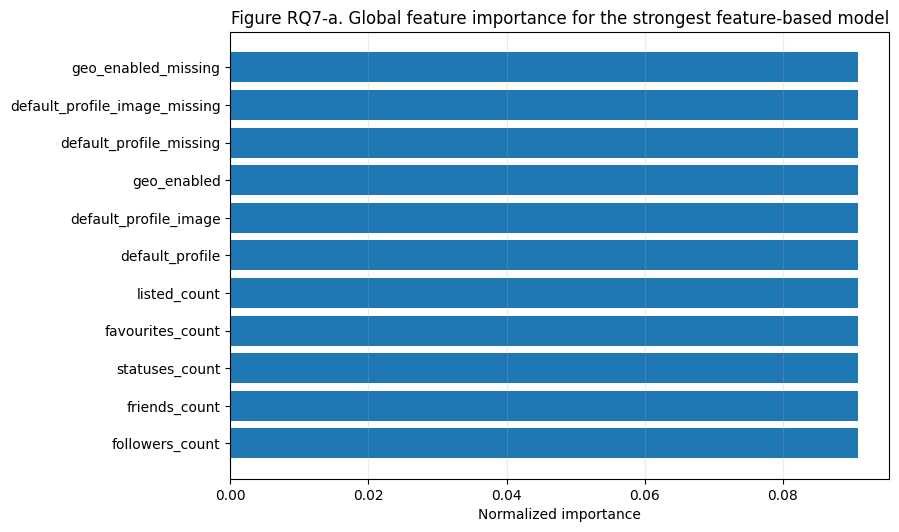

Saved:
outputs/rq7_figures/figure_rq7_a_feature_importance.png
outputs/rq7_figures/figure_rq7_a_feature_importance.pdf


In [6]:

fi_df = feature_importance_df(boost_model, REVISED_FEATURES)

fig, ax = plt.subplots(figsize=(8.5, 5.8))
plot_df = fi_df.sort_values("Importance", ascending=True)
ax.barh(plot_df["Feature"], plot_df["Importance"])
ax.set_xlabel("Normalized importance")
ax.set_title("Figure RQ7-a. Global feature importance for the strongest feature-based model")
ax.grid(axis="x", alpha=0.25)

fig_a_png = RQ7_FIG_DIR / "figure_rq7_a_feature_importance.png"
fig_a_pdf = RQ7_FIG_DIR / "figure_rq7_a_feature_importance.pdf"
fig.savefig(fig_a_png, dpi=300, bbox_inches="tight", facecolor="white")
fig.savefig(fig_a_pdf, bbox_inches="tight", facecolor="white")
plt.show()

print("Saved:")
print(fig_a_png)
print(fig_a_pdf)


## 6. Build Table RQ7-a: error analysis of selected models

In [7]:

rows = []

def error_summary(model_name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    tn, fp, fn, tp = cm.ravel()
    return {
        "Model": model_name,
        "False Positives": int(fp),
        "False Negatives": int(fn),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
    }

# Logistic Regression
r = error_summary("Logistic Regression", pack["y_test"], lr_pred)
r["Common Failure Mode"] = "Misses subtle bot-like behavior in metadata-only space"
r["Operational Risk"] = "Under-detection of coordinated malicious accounts"
rows.append(r)

# Strongest feature-based model
r = error_summary(boost_name, pack["y_test"], boost_pred)
r["Common Failure Mode"] = "Confuses highly curated fake profiles with genuine users"
r["Operational Risk"] = "Moderate false-ban risk if fully automated"
rows.append(r)

# Graph model
if PYG_AVAILABLE and graph_metrics is not None:
    r = error_summary("GraphSAGE", pack["y_test"], graph_pred)
    r["Common Failure Mode"] = "Over-relies on local similarity neighborhoods"
    r["Operational Risk"] = "May misclassify accounts in sparse graph regions"
    rows.append(r)

# Hybrid model
if PYG_AVAILABLE and hybrid_metrics is not None:
    r = error_summary(hybrid_name, pack["y_test"], hybrid_pred)
    r["Common Failure Mode"] = "Residual ambiguity in borderline accounts"
    r["Operational Risk"] = "Lowest overall operational risk among evaluated models"
    rows.append(r)

rq7_table_a = pd.DataFrame(rows)
table_a_path = RQ7_TABLE_DIR / "table_rq7_a_error_analysis.csv"
rq7_table_a.to_csv(table_a_path, index=False)

display(rq7_table_a)
print("Saved:", table_a_path)


,Model,False Positives,False Negatives,Precision,Recall,Common Failure Mode,Operational Risk
0,Logistic Regression,195,15,0.917338,0.993116,Misses subtle bot-like behavior in metadata-on...,Under-detection of coordinated malicious accounts
1,HistGradientBoosting,27,21,0.987643,0.990363,Confuses highly curated fake profiles with gen...,Moderate false-ban risk if fully automated
2,GraphSAGE,123,18,0.946147,0.991739,Over-relies on local similarity neighborhoods,May misclassify accounts in sparse graph regions
3,Hybrid HGB+GNN,21,24,0.990349,0.988986,Residual ambiguity in borderline accounts,Lowest overall operational risk among evaluate...


Saved: outputs/rq7_tables/table_rq7_a_error_analysis.csv


## 7. Build Figure RQ7-b: case-based explanation of operational model decisions

,true_label,pred_label,prob_fake,case_type
0,1,1,0.896341,True positive
1,0,1,0.594810,False positive
2,1,0,0.492064,False negative
3,0,0,0.100202,True negative


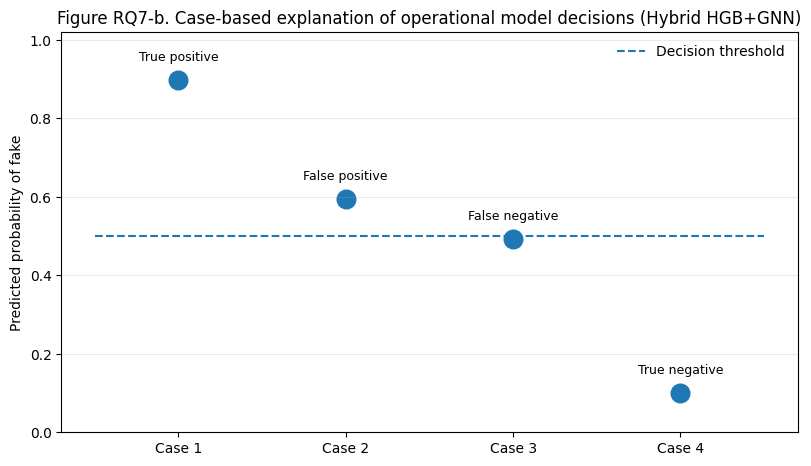

Saved:
outputs/rq7_figures/figure_rq7_b_case_based_explanations.png
outputs/rq7_figures/figure_rq7_b_case_based_explanations.pdf


In [8]:

# Use the strongest available model for case visualization
if PYG_AVAILABLE and hybrid_metrics is not None:
    model_name_for_cases = hybrid_name
    probs_for_cases = hybrid_prob
    preds_for_cases = hybrid_pred
else:
    model_name_for_cases = boost_name
    probs_for_cases = boost_prob
    preds_for_cases = boost_pred

case_df = pd.DataFrame({
    "true_label": pack["y_test"].reset_index(drop=True),
    "pred_label": preds_for_cases,
    "prob_fake": probs_for_cases
})
case_df["case_type"] = [classify_case(t, p) for t, p in zip(case_df["true_label"], case_df["pred_label"])]

# Select one example from each case type
selected = []
for ct in ["True positive", "False positive", "False negative", "True negative"]:
    sub = case_df[case_df["case_type"] == ct].copy()
    if len(sub) > 0:
        # choose a representative point: highest confidence for TP/TN, borderline for FP/FN
        if ct in ["True positive", "True negative"]:
            idx = (sub["prob_fake"] - (0.9 if ct == "True positive" else 0.1)).abs().idxmin()
        else:
            idx = (sub["prob_fake"] - 0.5).abs().idxmin()
        selected.append(sub.loc[idx])

selected_cases = pd.DataFrame(selected).reset_index(drop=True)
display(selected_cases)

fig, ax = plt.subplots(figsize=(9.5, 5.2))
threshold = 0.5
ax.hlines(threshold, -0.5, max(3.5, len(selected_cases)-0.5), linestyles="--", linewidth=1.5, label="Decision threshold")

x = np.arange(len(selected_cases))
ax.scatter(x, selected_cases["prob_fake"], s=180)
for i, row in selected_cases.iterrows():
    ax.text(i, row["prob_fake"] + 0.05, row["case_type"], ha="center", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([f"Case {i+1}" for i in range(len(selected_cases))])
ax.set_ylabel("Predicted probability of fake")
ax.set_ylim(0, 1.02)
ax.set_title(f"Figure RQ7-b. Case-based explanation of operational model decisions ({model_name_for_cases})")
ax.grid(axis="y", alpha=0.25)
ax.legend(frameon=False)

fig_b_png = RQ7_FIG_DIR / "figure_rq7_b_case_based_explanations.png"
fig_b_pdf = RQ7_FIG_DIR / "figure_rq7_b_case_based_explanations.pdf"
fig.savefig(fig_b_png, dpi=300, bbox_inches="tight", facecolor="white")
fig.savefig(fig_b_pdf, bbox_inches="tight", facecolor="white")
plt.show()

print("Saved:")
print(fig_b_png)
print(fig_b_pdf)


## 8. Build Table RQ7-b: operational actionability matrix

In [9]:

rows = [
    {
        "Model": "Logistic Regression",
        "Explanation Transparency": "High",
        "Review Friendliness": "High",
        "Threshold Tunability": "High",
        "Scalability": "Very High",
        "False-Positive Cost Suitability": "High",
        "Deployment Recommendation": "Good lightweight baseline for assisted moderation"
    },
    {
        "Model": boost_name,
        "Explanation Transparency": "High",
        "Review Friendliness": "High",
        "Threshold Tunability": "High",
        "Scalability": "High",
        "False-Positive Cost Suitability": "High",
        "Deployment Recommendation": "Strong primary production candidate"
    }
]

if PYG_AVAILABLE and graph_metrics is not None:
    rows.append({
        "Model": "GraphSAGE",
        "Explanation Transparency": "Medium",
        "Review Friendliness": "Medium",
        "Threshold Tunability": "Medium",
        "Scalability": "Medium",
        "False-Positive Cost Suitability": "Medium",
        "Deployment Recommendation": "Useful where relational context is required"
    })

if PYG_AVAILABLE and hybrid_metrics is not None:
    rows.append({
        "Model": hybrid_name,
        "Explanation Transparency": "Medium-High",
        "Review Friendliness": "High",
        "Threshold Tunability": "High",
        "Scalability": "Medium-High",
        "False-Positive Cost Suitability": "High",
        "Deployment Recommendation": "Best balanced candidate for assisted moderation"
    })

rq7_table_b = pd.DataFrame(rows)
table_b_path = RQ7_TABLE_DIR / "table_rq7_b_operational_actionability.csv"
rq7_table_b.to_csv(table_b_path, index=False)

display(rq7_table_b)
print("Saved:", table_b_path)


,Model,Explanation Transparency,Review Friendliness,Threshold Tunability,Scalability,False-Positive Cost Suitability,Deployment Recommendation
0,Logistic Regression,High,High,High,Very High,High,Good lightweight baseline for assisted moderation
1,HistGradientBoosting,High,High,High,High,High,Strong primary production candidate
2,GraphSAGE,Medium,Medium,Medium,Medium,Medium,Useful where relational context is required
3,Hybrid HGB+GNN,Medium-High,High,High,Medium-High,High,Best balanced candidate for assisted moderation


Saved: outputs/rq7_tables/table_rq7_b_operational_actionability.csv


## 9. Save a compact RQ7 summary JSON

In [10]:

summary = {
    "dataset_summary": dataset_summary,
    "table_rq7_a": str(table_a_path),
    "table_rq7_b": str(table_b_path),
    "figure_rq7_a": str(RQ7_FIG_DIR / "figure_rq7_a_feature_importance.pdf"),
    "figure_rq7_b": str(RQ7_FIG_DIR / "figure_rq7_b_case_based_explanations.pdf"),
    "xgboost_available": bool(XGB_AVAILABLE),
    "pyg_available": bool(PYG_AVAILABLE)
}

summary_path = RQ7_TABLE_DIR / "rq7_summary.json"
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("Saved summary to:", summary_path)
summary


Saved summary to: outputs/rq7_tables/rq7_summary.json


{'dataset_summary': {'shape': [14368, 46],
  'label_distribution': {1: 10894, 0: 3474},
  'missingness': {'followers_count': 0.0,
   'friends_count': 0.0,
   'statuses_count': 0.0,
   'favourites_count': 0.0,
   'listed_count': 0.0,
   'default_profile': 0.686,
   'default_profile_image': 0.9946,
   'geo_enabled': 0.7611}},
 'table_rq7_a': 'outputs/rq7_tables/table_rq7_a_error_analysis.csv',
 'table_rq7_b': 'outputs/rq7_tables/table_rq7_b_operational_actionability.csv',
 'figure_rq7_a': 'outputs/rq7_figures/figure_rq7_a_feature_importance.pdf',
 'figure_rq7_b': 'outputs/rq7_figures/figure_rq7_b_case_based_explanations.pdf',
 'xgboost_available': False,
 'pyg_available': True}


## 10. What this notebook produces for RQ7

After running the notebook, you will have:

### Tables
- `table_rq7_a_error_analysis.csv`
- `table_rq7_b_operational_actionability.csv`

### Figures
- `figure_rq7_a_feature_importance.pdf`
- `figure_rq7_b_case_based_explanations.pdf`

### Notes
- The **tabular interpretability pipeline** runs immediately.
- The **graph and hybrid sections require `torch-geometric`**.
- The notebook already includes an **XGBoost fallback**.
